# Trabajo Práctico 2: detector de máximo enfoque

Integrantes:
- Lucia T. Capon Paul
- Cesar Orellana
- Leandro Britez

### Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan lascámaras digitales modernas. El video a procesar será: “focus_video.mov”.

Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper"Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar los siguientes experimientos:

1. Medición sobre todo el frame.
2. Medición sobre una ROI ubicada en el centro del frame. Areade la ROI = 5 o 10% del areatotal del frame.

In [18]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Medición Frame completo

In [19]:
# Generamos función que calcula la medida de calidad de la imagen FM 

# La función recibe una imagen en escala de grises y devuelve el valor de FM
# La función sigue los pasos propuestos en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" 

def calculate_fm(gray_image):

    F = np.fft.fft2(gray_image) # Transformada de Fourier 2D

    Fc = np.fft.fftshift(F) # Desplazar el espectro de frecuencias al centro

    AF = np.abs(Fc) # Magnitud del espectro de frecuencias

    M = np.max(AF) # Valor máximo de la magnitud del espectro de frecuencias

    threshold = M / 1000 # Umbral para considerar una frecuencia como significativa (propuesto en paper)

    TH = np.sum(AF > threshold) # Contar el número de frecuencias significativas

    height, width = gray_image.shape

    FM = TH / (height * width) # Así el resultado no depende del tamaño de imagen

    return FM

Probamos sobre una imagen y validamos contra la misma blurreada, según el procedimiento que utilizan en la paper, esperando que el resultado de la imagen original tenga un resultado mucho mayor. 

In [ ]:
img = cv2.imread("guason.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fm = calculate_fm(gray)

print(f"FM = {fm}")

FM = 0.036462673611111114


In [21]:
blurred = cv2.GaussianBlur(gray, (9,9), 0)

fm_original = calculate_fm(gray)
fm_blurred = calculate_fm(blurred)

print("Original:", fm_original)
print("Blurred :", fm_blurred)

Original: 0.036462673611111114
Blurred : 0.01863474151234568


Se convalida la hipóstesis y se procede a trabajar con el vídeo. 

In [22]:
# Función para buscar el máximo enfoque

def detect_max_focus(fm_values):

    max_frame = np.argmax(fm_values)
    max_fm = fm_values[max_frame]

    return max_frame, max_fm

In [ ]:
# Realizamos la detección del frame de máximo enfoque

# Abrimos el video
cap = cv2.VideoCapture("focus_video.mov")

fm_values = []
frame_numbers = []

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    fm = calculate_fm(gray)

    fm_values.append(fm)
    frame_numbers.append(frame_idx)

    frame_idx += 1

cap.release()

### Buscar el máximo enfoque

In [24]:
max_frame, max_fm = detect_max_focus(fm_values)

print(f"Frame de máximo enfoque: {max_frame}")
print(f"Valor FM: {max_fm:.6f}")

Frame de máximo enfoque: 109
Valor FM: 0.028624


### Plotear la evolución de enfoque por cada frame

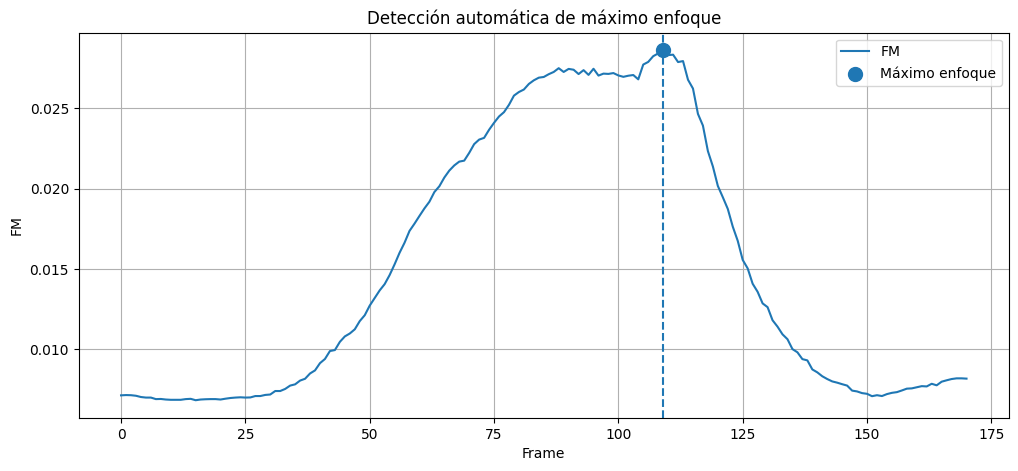

In [25]:
plt.figure(figsize=(12,5))

plt.plot(frame_numbers, fm_values, label="FM")

plt.scatter(
    max_frame,
    max_fm,
    s=100,
    label="Máximo enfoque"
)

plt.axvline(
    max_frame,
    linestyle="--"
)

plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Detección automática de máximo enfoque")

plt.legend()
plt.grid(True)

plt.show()

## Mostramos el frame de máximo enfoque

In [26]:
cap = cv2.VideoCapture("focus_video.mov")

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    if frame_idx == max_frame:
        best_frame = frame.copy()
        break

    frame_idx += 1

cap.release()

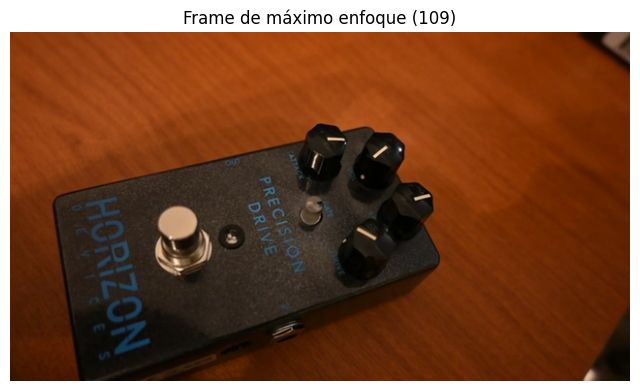

In [27]:
plt.figure(figsize=(8,6))

plt.imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))

plt.title(
    f"Frame de máximo enfoque ({max_frame})"
)

plt.axis("off")

plt.show()

Para cada frame del video se calculó la métrica FM propuesta en el paper. Posteriormente se implementó un detector automático de enfoque máximo, el cual identifica el frame asociado al valor máximo de FM utilizando una búsqueda del máximo global sobre la serie temporal de medidas obtenidas. El algoritmo devuelve automáticamente el número de frame y el valor FM correspondiente al punto de máximo enfoque.

# 2. Medición sobre ROI = 10% 



In [29]:
def get_center_roi(image, roi_percentage=0.10):

    h, w = image.shape[:2]

    scale = np.sqrt(roi_percentage)

    roi_w = int(w * scale)
    roi_h = int(h * scale)

    x1 = (w - roi_w) // 2
    y1 = (h - roi_h) // 2

    x2 = x1 + roi_w
    y2 = y1 + roi_h

    roi = image[y1:y2, x1:x2]

    return roi

Rvisamos si la captura del ROI está centrada y es representativa 

In [30]:
cap = cv2.VideoCapture("focus_video.mov")

ret, frame = cap.read()

cap.release()

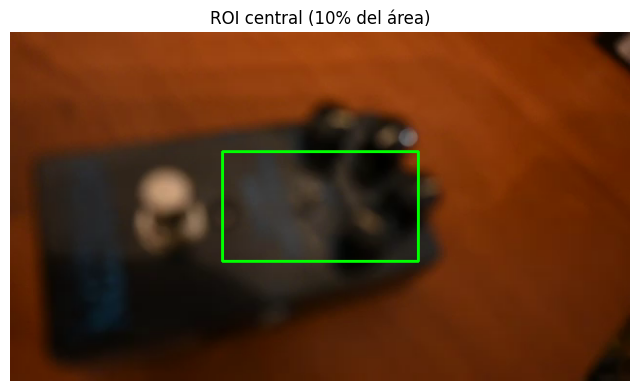

In [32]:
frame_copy = frame.copy()

h, w = frame.shape[:2]

scale = np.sqrt(0.10)

roi_w = int(w * scale)
roi_h = int(h * scale)

x1 = (w - roi_w) // 2
y1 = (h - roi_h) // 2

x2 = x1 + roi_w
y2 = y1 + roi_h

cv2.rectangle(
    frame_copy,
    (x1, y1),
    (x2, y2),
    (0,255,0),
    2
)

plt.figure(figsize=(8,6))

plt.imshow(cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB))

plt.title("ROI central (10% del área)")

plt.axis("off")

plt.show()

In [37]:
# Realizamos la detección del frame de máximo enfoque ROI

# Abrimos el video
cap = cv2.VideoCapture("focus_video.mov")

fm_values_roi = []
frame_numbers_roi = []

frame_idx = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    roi = get_center_roi(frame, 0.10) # Extraemos la ROI central (10% del área)

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    fm = calculate_fm(gray)

    fm_values_roi.append(fm)
    frame_numbers_roi.append(frame_idx)

    frame_idx += 1

cap.release()

In [39]:
max_frame_roi, max_fm_roi = detect_max_focus(fm_values_roi)

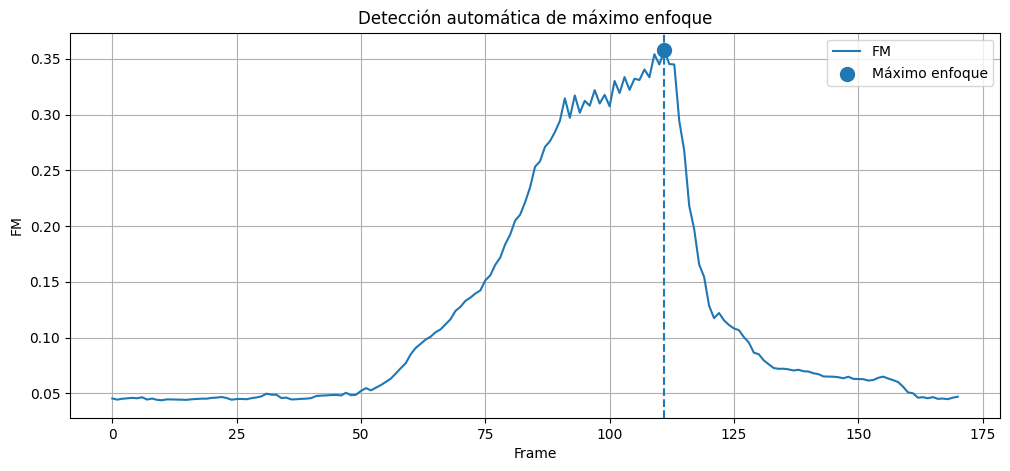

In [40]:
plt.figure(figsize=(12,5))

plt.plot(frame_numbers_roi, fm_values_roi, label="FM")

plt.scatter(
    max_frame_roi,
    max_fm_roi,
    s=100,
    label="Máximo enfoque"
)

plt.axvline(
    max_frame_roi,
    linestyle="--"
)

plt.xlabel("Frame")
plt.ylabel("FM")
plt.title("Detección automática de máximo enfoque")

plt.legend()
plt.grid(True)

plt.show()

# Resultados y conclusiones

In [44]:
print(
    f"""
=== Experimento 1: Frame completo ===

Máximo enfoque detectado: Frame {max_frame}
Valor FM máximo: {max_fm:.6f}

"""
)

print(
    f"""
=== Experimento 2: ROI central 10% ===

Máximo enfoque detectado: Frame {max_frame_roi}
Valor FM máximo: {max_fm_roi:.6f}

"""
)


=== Experimento 1: Frame completo ===

Máximo enfoque detectado: Frame 109
Valor FM máximo: 0.028624



=== Experimento 2: ROI central 10% ===

Máximo enfoque detectado: Frame 111
Valor FM máximo: 0.357706




Se implementó la métrica FM propuesta en el paper y se aplicó sobre todos los frames del video para detectar automáticamente el punto de máximo enfoque.

En el experimento 1 realizado sobre el frame completo, el algoritmo detectó el máximo enfoque en el frame 109 con un valor FM de 0.028624. Posteriormente se repitió el análisis utilizando una ROI central equivalente al 10% del área de la imagen. En este caso, el máximo enfoque fue detectado en el frame 111 con un valor FM de 0.357706.

La diferencia es de únicamente dos frames entre ambos resultados, lo que indica que ambos métodos identifican la misma zona temporal de máximo enfoque. Sin embargo, la ROI presentó valores FM mcho más elevados, lo que podría indicar que tiene mayor sensibilidad a los detalles presentes en la región central de la imagen. Esto se debe a que la evaluación se concentra sobre la zona de interés. 

